## Looking at NDVI (vegetative health) at Tubarjal province, Saudi Arabia 2018-2023

In [1]:
# Install missing Python libraries
!pip install osmnx

In [2]:
# Import python libraries
import getpass
import json
import os
import pathlib
from glob import glob

# Library to work with tabular data
import pandas as pd

# Library to work with vector data
import geopandas as gpd

import earthpy.appeears as eaapp
import hvplot.pandas 
import hvplot.xarray
import rioxarray as rxr
import xarray as xr # uses numpy
import matplotlib.pyplot as plt

# Library to search for boundaries
from osmnx import features as osm # Search for locations by name

In [3]:
# Set path to data
tubarjal_dir = os.path.join(pathlib.Path.home(), 'tubarjal-data')

# Make the data directory
os.makedirs(tubarjal_dir, exist_ok=True)

tubarjal_dir

'/home/jovyan/tubarjal-data'

## Download the vector boundary data (Shapefile) using OpenStreetMap

In [4]:
# Get boundary for Tubarjal from OSM
tubarjal_gdf = osm.features_from_address(
    "Tubarjal",
    {"boundary": "administrative"},
    dist=1000)
tubarjal_gdf

geometry  \
element  id                                                            
relation 12413344  POLYGON ((37.45751 29.92079, 37.45745 29.92187...   
         19307220  POLYGON ((38.21064 30.51661, 38.21116 30.51696...   
         19307228  POLYGON ((38.22343 30.50461, 38.22485 30.50629...   
         19307229  POLYGON ((38.22438 30.49444, 38.22582 30.4967,...   
         19307230  POLYGON ((38.2154 30.47431, 38.21612 30.475, 3...   
         19307231  POLYGON ((38.19667 30.51787, 38.1968 30.51813,...   
         19307232  POLYGON ((38.14333 30.54824, 38.14685 30.55216...   
         19307233  POLYGON ((38.19673 30.50304, 38.19673 30.50332...   
         19307234  POLYGON ((38.21358 30.49292, 38.21509 30.4947,...   
         19307235  POLYGON ((38.1996 30.48366, 38.19967 30.4837, ...   

                  admin_level        boundary      type          name  \
element  id                                                             
relation 12413344           6  administrative  boundary  محافظة طبرجل   
         19307220          10  administrative  boundary        المروة   
         19307228          10  administrative  boundary         الصفا   
         19307229          10  administrative  boundary        النسيم   
         19307230          10  administrative  boundary        الربيع   
         19307231          10  administrative  boundary          حدرج   
         19307232          10  administrative  boundary       الخزامى   
         19307233          10  administrative  boundary      الخالدية   
         19307234          10  administrative  boundary      العزيزية   
         19307235          10  administrative  boundary       الزيتون   

                        name:ar        name:en     place  wikidata  \
element  id                                                          
relation 12413344  محافظة طبرجل       Tubarjal  province  Q7672929   
         19307220        المروة      Al Marwah       NaN       NaN   
         19307228         الصفا        Al Safa       NaN       NaN   
         19307229        النسيم      Al Naseem       NaN       NaN   
         19307230        الربيع       Ar Rabie       NaN       NaN   
         19307231          حدرج         Hadraj       NaN       NaN   
         19307232       الخزامى     Al Khuzama       NaN       NaN   
         19307233      الخالدية  Al Khalidiyah       NaN       NaN   
         19307234      العزيزية    Al Aziziyah       NaN       NaN   
         19307235       الزيتون      Az Zaytun       NaN       NaN   

                     wikipedia  
element  id                     
relation 12413344  en:Tabarjal  
         19307220          NaN  
         19307228          NaN  
         19307229          NaN  
         19307230          NaN  
         19307231          NaN  
         19307232          NaN  
         19307233          NaN  
         19307234          NaN  
         19307235          NaN

In [5]:
# Select out just the province boundary
tubarjal_province_gdf = tubarjal_gdf[tubarjal_gdf["name:en"]=="Tubarjal"]
tubarjal_province_gdf

,,geometry,admin_level,boundary,type,name,name:ar,name:en,place,wikidata,wikipedia
element,id,,,,,,,,,,
relation,12413344,"POLYGON ((37.45751 29.92079, 37.45745 29.92187...",6,administrative,boundary,محافظة طبرجل,محافظة طبرجل,Tubarjal,province,Q7672929,en:Tabarjal


<Axes: >

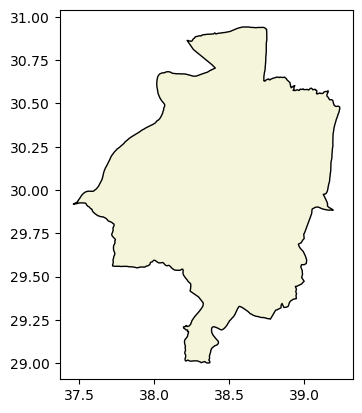

In [6]:
# Plot Tubarjal
tubarjal_province_gdf.plot(color='beige', edgecolor='black')

## Downloading raster NDVI .tif data using NASA AppEEARS

In [7]:
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader = eaapp.AppeearsDownloader(
    download_key='tubarjal-ndvi',
    ea_dir=tubarjal_dir,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    start_date="07-01",
    end_date="07-31",
    recurring=True,
    year_range=[2018, 2023],
    polygon=tubarjal_province_gdf
)

ndvi_downloader.download_files(cache=True)

In [8]:
# Get a list of NDVI tif file paths for Tubarjal
ndvi_paths_tubarjal = sorted(glob(os.path.join(tubarjal_dir, 'tubarjal-ndvi', '*', '*NDVI*.tif')))
len(ndvi_paths_tubarjal)

18

In [9]:
# Look at Tubarjal NDVI data paths
ndvi_paths_tubarjal

['/home/jovyan/tubarjal-data/tubarjal-ndvi/MOD13Q1.061_2018167_to_2023212/MOD13Q1.061__250m_16_days_NDVI_doy2018177000000_aid0001.tif',
 '/home/jovyan/tubarjal-data/tubarjal-ndvi/MOD13Q1.061_2018167_to_2023212/MOD13Q1.061__250m_16_days_NDVI_doy2018193000000_aid0001.tif',
 '/home/jovyan/tubarjal-data/tubarjal-ndvi/MOD13Q1.061_2018167_to_2023212/MOD13Q1.061__250m_16_days_NDVI_doy2018209000000_aid0001.tif',
 '/home/jovyan/tubarjal-data/tubarjal-ndvi/MOD13Q1.061_2018167_to_2023212/MOD13Q1.061__250m_16_days_NDVI_doy2019177000000_aid0001.tif',
 '/home/jovyan/tubarjal-data/tubarjal-ndvi/MOD13Q1.061_2018167_to_2023212/MOD13Q1.061__250m_16_days_NDVI_doy2019193000000_aid0001.tif',
 '/home/jovyan/tubarjal-data/tubarjal-ndvi/MOD13Q1.061_2018167_to_2023212/MOD13Q1.061__250m_16_days_NDVI_doy2019209000000_aid0001.tif',
 '/home/jovyan/tubarjal-data/tubarjal-ndvi/MOD13Q1.061_2018167_to_2023212/MOD13Q1.061__250m_16_days_NDVI_doy2020177000000_aid0001.tif',
 '/home/jovyan/tubarjal-data/tubarjal-ndvi/MOD13

In [11]:
scale_factor=10000
doy_start = -25
doy_end = -18

In [12]:
# Loop through Tubarjal NDVI data
tubarjal_ndvi_das = []
for ndvi_path in ndvi_paths_tubarjal:
    # Get date from file name
    doy = ndvi_path[doy_start:doy_end]
    date = pd.to_datetime(doy, format='%Y%j')

    # Open dataset
    da = rxr.open_rasterio(ndvi_path, masked=True).squeeze()

    # Add date dimension and clean up metadata
    da = da.assign_coords({'date': date})
    da = da.expand_dims({'date': 1})
    da.name = 'NDVI'

    # Multiple by scale factor
    da = da / scale_factor

    # Prepare for concatenation
    tubarjal_ndvi_das.append(da)

len(tubarjal_ndvi_das)

18

In [13]:
# Look at das
tubarjal_ndvi_das

[<xarray.DataArray 'NDVI' (date: 1, y: 932, x: 853)>
 array([[[0.1111, 0.1099, 0.1065, ..., 0.0897, 0.0914, 0.0889],
         [0.1135, 0.1111, 0.1128, ..., 0.092 , 0.0909, 0.0887],
         [0.1189, 0.1189, 0.1138, ..., 0.0917, 0.0917, 0.0899],
         ...,
         [0.0929, 0.0875, 0.0837, ..., 0.1273, 0.1279, 0.1279],
         [0.0875, 0.0875, 0.0929, ..., 0.129 , 0.1262, 0.1281],
         [0.095 , 0.095 , 0.0992, ..., 0.1278, 0.1291, 0.1297]]],
       dtype=float32)
 Coordinates:
     band         int64 1
   * x            (x) float64 37.46 37.46 37.46 37.46 ... 39.23 39.23 39.23 39.23
   * y            (y) float64 30.94 30.94 30.94 30.94 ... 29.01 29.01 29.01 29.01
     spatial_ref  int64 0
   * date         (date) datetime64[ns] 2018-06-26,
 <xarray.DataArray 'NDVI' (date: 1, y: 932, x: 853)>
 array([[[0.1074, 0.1065, 0.1128, ..., 0.0958, 0.0935, 0.0951],
         [0.1118, 0.1148, 0.1152, ..., 0.0927, 0.0939, 0.0938],
         [0.119 , 0.119 , 0.1168, ..., 0.0954, 0.0954, 0.0938]

In [14]:
# Combine das into single da (organized by date)
tubarjal_ndvi_da = xr.combine_by_coords(tubarjal_ndvi_das, coords=['date'])
tubarjal_ndvi_da

<xarray.Dataset>
Dimensions:      (x: 853, y: 932, date: 18)
Coordinates:
    band         int64 1
  * x            (x) float64 37.46 37.46 37.46 37.46 ... 39.23 39.23 39.23 39.23
  * y            (y) float64 30.94 30.94 30.94 30.94 ... 29.01 29.01 29.01 29.01
    spatial_ref  int64 0
  * date         (date) datetime64[ns] 2018-06-26 2018-07-12 ... 2023-07-28
Data variables:
    NDVI         (date, y, x) float32 0.1111 0.1099 0.1065 ... 0.1368 0.1363

In [15]:
# Compute the difference in NDVI before and after the irrigation
tubarjal_ndvi_diff = (
    tubarjal_ndvi_da
        .sel(date=slice('2021', '2023'))
        .mean('date')
        .NDVI 
   - tubarjal_ndvi_da
        .sel(date=slice('2018', '2020'))
        .mean('date')
        .NDVI
)

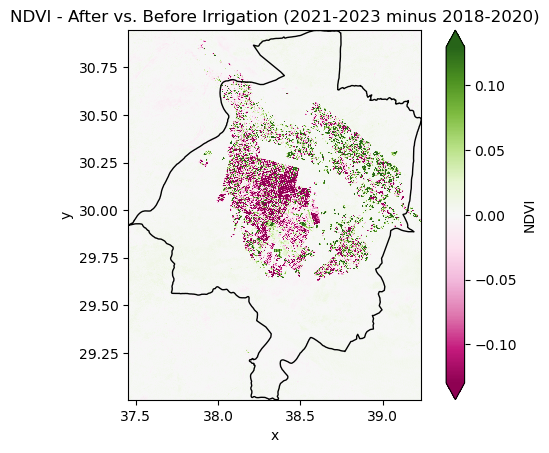

In [16]:
# Plot the difference
fig, ax = plt.subplots()

tubarjal_ndvi_diff.plot(x='x', y='y', cmap='PiYG', robust=True, ax=ax)
tubarjal_province_gdf.plot(edgecolor='black', color='none', ax=ax)
plt.title("NDVI - After vs. Before Irrigation (2021-2023 minus 2018-2020)")
plt.show()